### importing necessary libraries

In [1]:
import os
import pandas as pd
import numpy as np
import time
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

import inspect
import traceback
import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(
    style = "whitegrid",
    palette = "colorblind",
    context = "notebook"
)

In [3]:
np.set_printoptions(precision = 4 , suppress = True)
pd.set_option("display.float_format" , "{:.4f}".format)

In [4]:
plt.style.use("seaborn-v0_8")
plt.rcParams.update({
    "axes.titlesize" : 12,
    "axes.labelsize" : 8,
    "axes.grid" : True,
    "font.size" : 4,
    "lines.linewidth" : 3
})

### loaing installed python packages

In [5]:
from src.utils.config import INTERIM,ROOT_DIR,CLEAN_DATA_FILE,FIGURES
from src.data import outliers_and_narmalization
from src.features import statistical_tests

Lahore Real Estate Price Prediction Pipeline


In [6]:
lohor_dataset = pd.read_csv(ROOT_DIR/INTERIM/CLEAN_DATA_FILE)
lohor_dataset.head(2)

,Title,Location,Type,Price,Area,Bedrooms,Bathrooms,Purpose,Kitchens,Store_Rooms,...,Study_Room,Drawing_Room,Dining_Room,Lawn_Garden,Swimming_Pool,Electricity_Backup,Lounge_Sitting_Room,Link,Area_sqft,Price_PKR
0,ACTUALLY 25 MARLA DOUBLE UNIT LUXURIOUS & GRAC...,"DHA Phase 6 - Block F, DHA Phase 6, DHA Defenc...",House,8.15 Crore,1 Kanal,6.0000,7.0000,For Sale,3,2,...,True,True,True,True,True,True,True,https://www.zameen.com/Property/dha_phase_6_dh...,4500.0000,81500000.0000
1,3 Years Installment Plan Luxury Brand New Hous...,"Park View City, Lahore, Punjab",House,1.5 Crore,5 Marla,4.0000,5.0000,For Sale,2,1,...,False,True,True,True,False,True,True,https://www.zameen.com/Property/lahore_park_vi...,1125.0000,15000000.0000


In [7]:
lohor_dataset.describe()

,Bedrooms,Bathrooms,Kitchens,Store_Rooms,Servant_Quarters,Area_sqft,Price_PKR
count,17808.0000,17808.0000,17808.0000,17808.0000,17808.0000,17808.0000,17808.0000
mean,4.4104,5.0697,1.6846,0.7989,0.8606,2795.9320,58230869.5735
std,1.2086,1.2107,1.0594,0.7841,1.2519,2698.2802,78512672.6699
min,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,8.0000
25%,3.0000,4.0000,1.0000,0.0000,0.0000,1125.0000,21000000.0000
50%,5.0000,5.0000,2.0000,1.0000,1.0000,2250.0000,36000000.0000
75%,5.0000,6.0000,2.0000,1.0000,1.0000,4500.0000,71000000.0000
max,11.0000,8.0000,32.0000,22.0000,111.0000,90000.0000,2000000000.0000


In [8]:
lohor_dataset.drop(columns = "Link",inplace = True)
cat_cols = lohor_dataset.select_dtypes(include = "object").columns

In [9]:
lohor_dataset[cat_cols].describe()

,Title,Location,Type,Price,Area,Purpose
count,17808,17808,17808,17808,17808,17808
unique,14956,1281,1,932,136,1
top,3 Years Installment Plan Luxury Brand New Hous...,"DHA Phase 6, DHA Defence, Lahore, Punjab",House,2.1 Crore,5 Marla,For Sale
freq,59,1009,17808,334,4908,17808


In [10]:
lohor_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17808 entries, 0 to 17807
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                17808 non-null  object 
 1   Location             17808 non-null  object 
 2   Type                 17808 non-null  object 
 3   Price                17808 non-null  object 
 4   Area                 17808 non-null  object 
 5   Bedrooms             17808 non-null  float64
 6   Bathrooms            17808 non-null  float64
 7   Purpose              17808 non-null  object 
 8   Kitchens             17808 non-null  int64  
 9   Store_Rooms          17808 non-null  int64  
 10  Servant_Quarters     17808 non-null  int64  
 11  Furnished            17808 non-null  bool   
 12  Gym                  17808 non-null  bool   
 13  Study_Room           17808 non-null  bool   
 14  Drawing_Room         17808 non-null  bool   
 15  Dining_Room          17808 non-null 

### Exploratory Data Analysis (EDA)

In [11]:
num_cols = lohor_dataset.select_dtypes(include = np.number).columns
cat_cols = lohor_dataset.select_dtypes(include = "object").columns
cat_cols

Index(['Title', 'Location', 'Type', 'Price', 'Area', 'Purpose'], dtype='object')

In [12]:
num_cols

Index(['Bedrooms', 'Bathrooms', 'Kitchens', 'Store_Rooms', 'Servant_Quarters',
       'Area_sqft', 'Price_PKR'],
      dtype='object')

In [13]:
bool_cols = lohor_dataset.select_dtypes(include = bool).columns
bool_cols

Index(['Furnished', 'Gym', 'Study_Room', 'Drawing_Room', 'Dining_Room',
       'Lawn_Garden', 'Swimming_Pool', 'Electricity_Backup',
       'Lounge_Sitting_Room'],
      dtype='object')

In [14]:
lohor_dataset["Title"].nunique()

14956

In [15]:
len(lohor_dataset[lohor_dataset["Title"].duplicated()])

2852

In [16]:
lohor_dataset.groupby("Location").count().head(10).index.to_list()

['AWT Phase 2 - Block A, AWT Phase 2, AWT Army Welfare Trust, Raiwind Road, Lahore, Punjab',
 'AWT Phase 2 - Block C, AWT Phase 2, AWT Army Welfare Trust, Raiwind Road, Lahore, Punjab',
 'AWT Phase 2 - Block D, AWT Phase 2, AWT Army Welfare Trust, Raiwind Road, Lahore, Punjab',
 'AWT Phase 2 - Block E-1, AWT Phase 2, AWT Army Welfare Trust, Raiwind Road, Lahore, Punjab',
 'AWT Phase 2, AWT Army Welfare Trust, Raiwind Road, Lahore, Punjab',
 'Aabpara Coop Housing Society, Lahore, Punjab',
 'Aamir Town, Harbanspura, Lahore, Punjab',
 'Aashiana Road, Lahore, Punjab',
 'Abbas Block, Mustafa Town, Lahore, Punjab',
 'Abdalians Cooperative Housing Society, Lahore, Punjab']

In [17]:
lohor_dataset.groupby("Title").count().head(10).index.to_list()

['" PRIME LOCATION VIP LINE" 5 MARLA FULLY FURNISHED HOUSE FOR SALE.',
 '"1 Kanal Brand New Luxury Villa | Golf Course Facing | For Sale"',
 '"1 Kanal Fully Furnished Luxury House for Sale in DHA Phase 7 Prime Location | Designer Living"',
 '"6 Marla Double Unit House For Sale In DHA Phase 5 J Block - Nearby Park &Amp; All Necessities"',
 '"Charming 3 Bedroom 5 Marla House In DHA Modern Comfort With Stylish Finishes"',
 '"Charming 3 Bedrooms 5 Marla House In DHA Modern Comfort With Stylish Finishes"',
 '"Charming 3-Bedroom 5 Marla House In DHA Modern Comfort With Stylish Finishes"',
 '"Charming 3-Bedroom 5 Marla House in DHA Modern Comfort with Stylish Finishes"',
 '"Dream Home Awaits: Exquisite 5-Bed Luxury Retreat on 18 Marla!"',
 '"Elegant 1 Kanal Home In Phase 7: Modern Luxury And Prime Location']

In [18]:
#plots int columns desctribution
def count_plot(col):
    plt.figure(figsize=(8, 5))
    sns.countplot(data=lohor_dataset,x=col)

    plt.title(f"Count Plot for {col}")
    plt.xlabel("Category")
    plt.ylabel("Count")
    os.chdir(ROOT_DIR/FIGURES)
    plt.savefig(f"{col}_EDA_plot.jpg")
    plt.show()

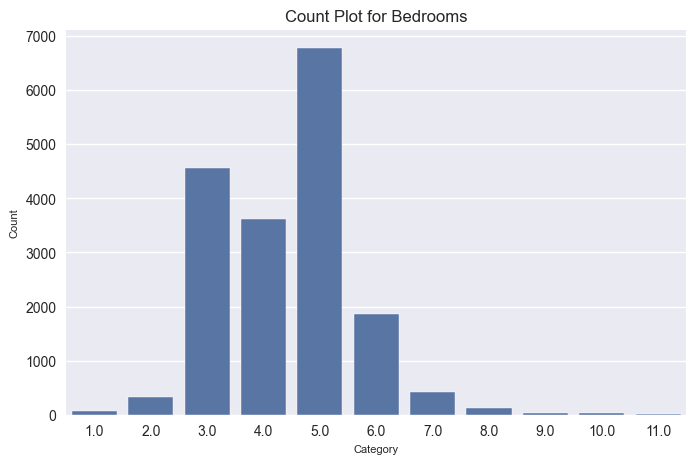

In [19]:
count_plot("Bedrooms")

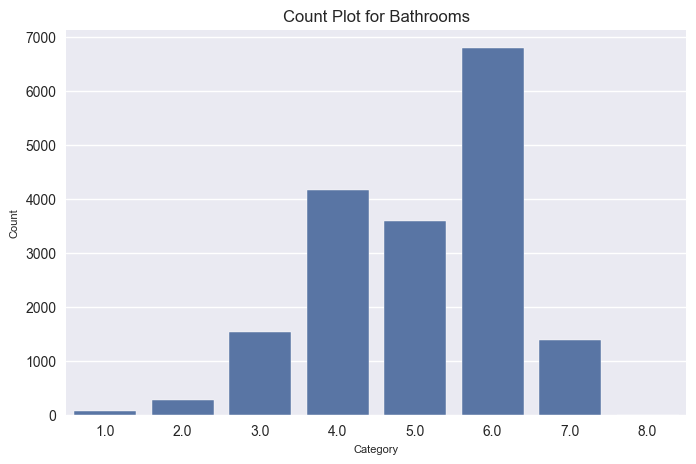

In [20]:
count_plot("Bathrooms")

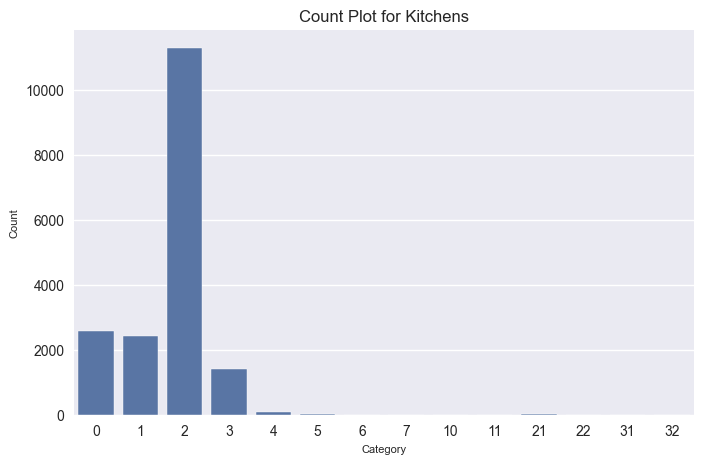

In [21]:
count_plot("Kitchens")

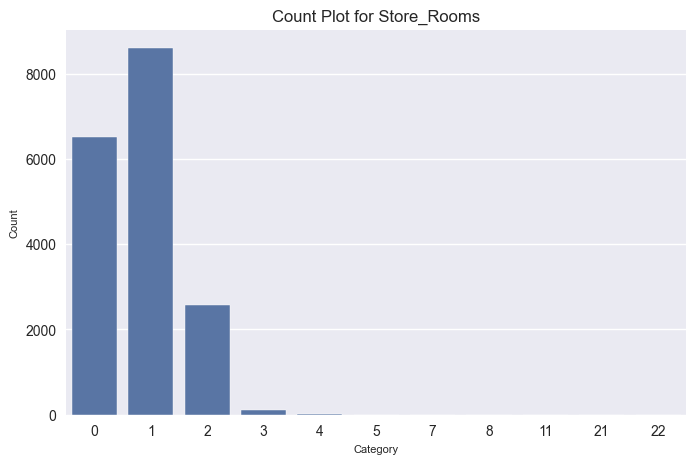

In [22]:
count_plot("Store_Rooms")

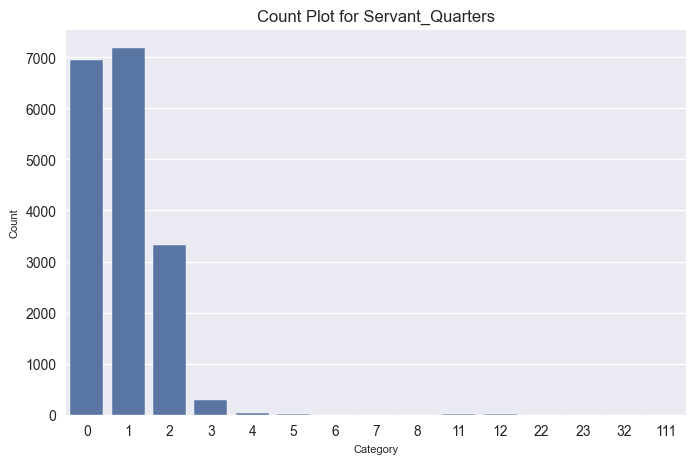

In [23]:
count_plot("Servant_Quarters")

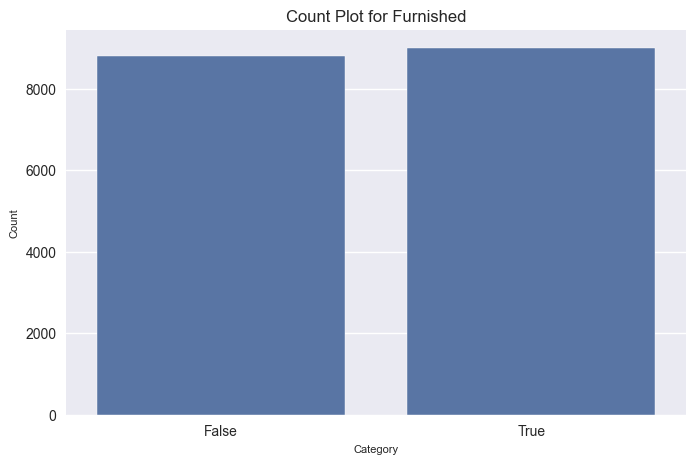

In [24]:
count_plot("Furnished")

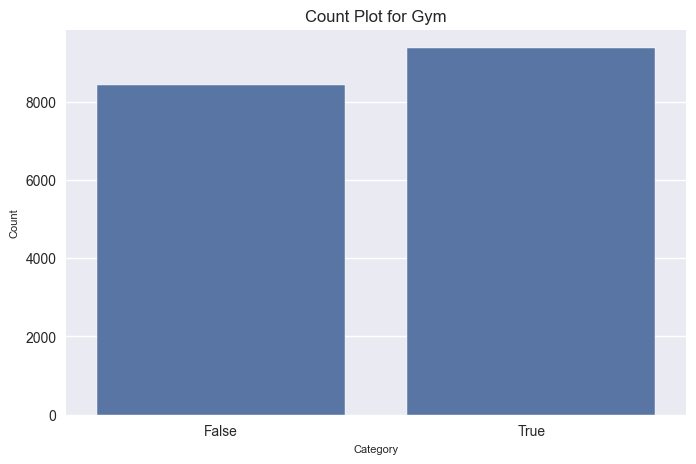

In [25]:
count_plot("Gym")

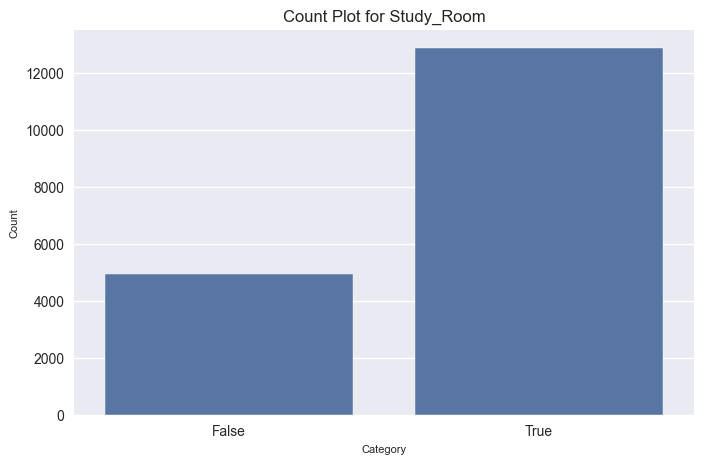

In [26]:
count_plot("Study_Room")

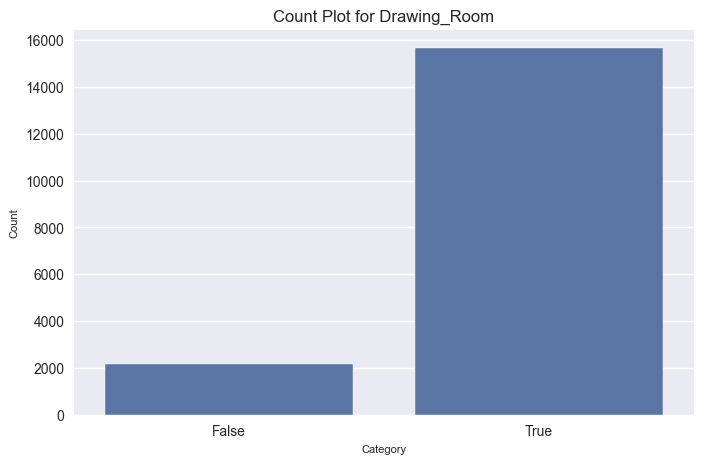

In [27]:
count_plot("Drawing_Room")

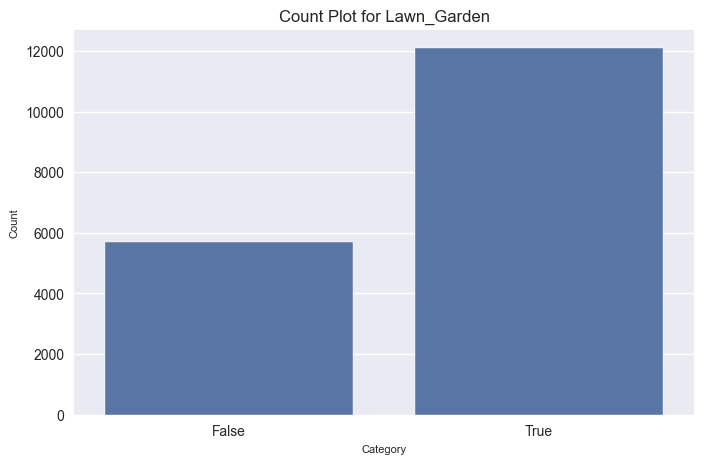

In [28]:
count_plot("Lawn_Garden")

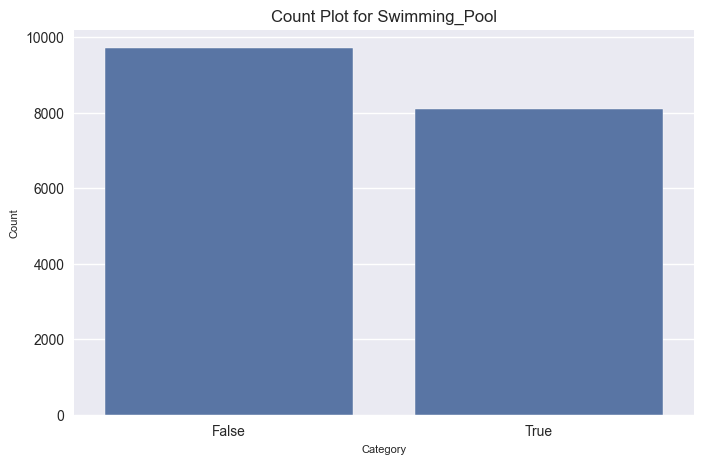

In [29]:
count_plot("Swimming_Pool")

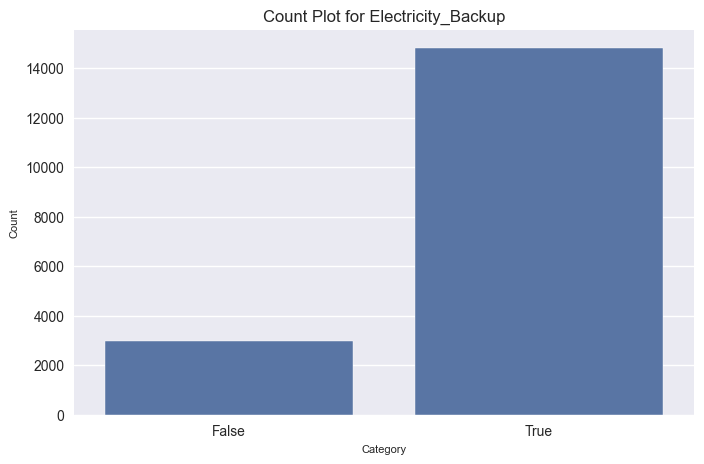

In [30]:
count_plot("Electricity_Backup")

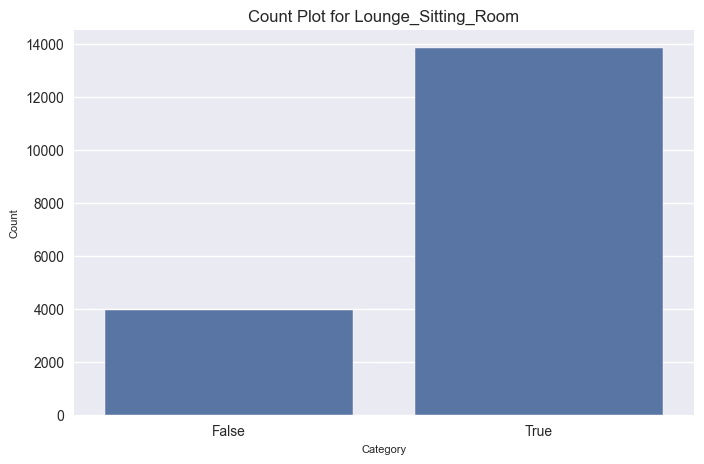

In [31]:
count_plot("Lounge_Sitting_Room")

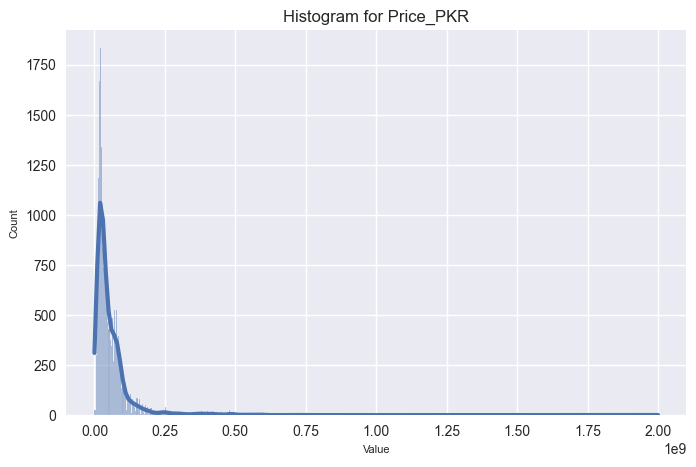

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(data=lohor_dataset,x="Price_PKR",kde=True)
os.chdir(ROOT_DIR/FIGURES)
plt.savefig("Price_PKR_EDA_plot.jpg")
plt.title("Histogram for Price_PKR")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()

In [33]:
lohor_dataset = outliers_and_narmalization.handling_outliers(lohor_dataset)

Removed 79 outlier rows.
Remaining rows: 17729


In [34]:
lohor_dataset["Location_Normalized"] = lohor_dataset["Location"].apply(outliers_and_narmalization.location_granularity)

In [35]:
lohor_dataset["Location"].unique()

array(['DHA Phase 6 - Block F, DHA Phase 6, DHA Defence, Lahore, Punjab',
       'Park View City, Lahore, Punjab',
       'Park View City - Rose Block, Park View City, Lahore, Punjab', ...,
       'Government Employees Cooperative Housing Society (GECHS), Lahore, Punjab',
       'Tajpura - Block D, Tajpura, Lahore, Punjab',
       'Bismillah Housing Scheme - Iqbal Block, Bismillah Housing Scheme, GT Road, Lahore, Punjab'],
      shape=(1278,), dtype=object)

In [36]:
lohor_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17729 entries, 0 to 17807
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                17729 non-null  object 
 1   Location             17729 non-null  object 
 2   Type                 17729 non-null  object 
 3   Price                17729 non-null  object 
 4   Area                 17729 non-null  object 
 5   Bedrooms             17729 non-null  float64
 6   Bathrooms            17729 non-null  float64
 7   Purpose              17729 non-null  object 
 8   Kitchens             17729 non-null  int64  
 9   Store_Rooms          17729 non-null  int64  
 10  Servant_Quarters     17729 non-null  int64  
 11  Furnished            17729 non-null  bool   
 12  Gym                  17729 non-null  bool   
 13  Study_Room           17729 non-null  bool   
 14  Drawing_Room         17729 non-null  bool   
 15  Dining_Room          17729 non-null  bool

In [37]:
lohor_dataset.groupby("Location_Normalized")["Price_PKR"].sum().head(10).sort_values(ascending = False)

Location_Normalized
Al Rehman Garden                        5924445000.0000
Al Hafeez Gardens                        677200000.0000
AWT Army Welfare Trust                   650300000.0000
AWT Phase 2                              344500000.0000
Abdalians Cooperative Housing Society    204500000.0000
Al Jalil Garden                          137300000.0000
Al Kareem Garden                          60000000.0000
Al Haram Garden                           49000000.0000
Al Hafeez Garden - Phase 2                19900000.0000
Al Noor Park Housing Society              16900000.0000
Name: Price_PKR, dtype: float64

### Kruskal-Wallis-Test(Categorical Vs Numerical)

In [38]:
statistical_tests.kruskal_wallis(lohor_dataset,"Location_Normalized")

Result: Significant relationship with Price_PKR (Reject H₀)


{'H statistic': np.float64(8827.190545421092),
 'p-value': np.float64(0.0),
 'Post-hoc':                                        AWT Army Welfare Trust  AWT Phase 2  \
 AWT Army Welfare Trust                                 1.0000       1.0000   
 AWT Phase 2                                            1.0000       1.0000   
 Abdalians Cooperative Housing Society                  1.0000       1.0000   
 Al Hafeez Garden - Phase 2                             1.0000       1.0000   
 Al Hafeez Gardens                                      1.0000       0.5548   
 ...                                                       ...          ...   
 Vital Homes Housing Scheme                             0.0620       0.0136   
 Wagha Town                                             1.0000       1.0000   
 Walton Road                                            1.0000       1.0000   
 Wapda Town                                             1.0000       1.0000   
 Zaamin City Phase 1                       

In [39]:
#statistical_tests.kruskal_wallis(lohor_dataset,"Title")

- **Kruskal-Wallis-Test gives there is significant defference between each location on Price features.**
- **it suggests, location usefull for predictions.**

In [40]:
#simple correlation against to taget variable price
corr = lohor_dataset.corr(numeric_only=True)["Price_PKR"]
corr

Bedrooms              0.5243
Bathrooms             0.4963
Kitchens              0.1295
Store_Rooms           0.2114
Servant_Quarters      0.2248
Furnished             0.1233
Gym                   0.0807
Study_Room            0.1358
Drawing_Room          0.0717
Dining_Room           0.0915
Lawn_Garden           0.1385
Swimming_Pool         0.0920
Electricity_Backup    0.1068
Lounge_Sitting_Room   0.0808
Area_sqft             0.8055
Price_PKR             1.0000
Name: Price_PKR, dtype: float64

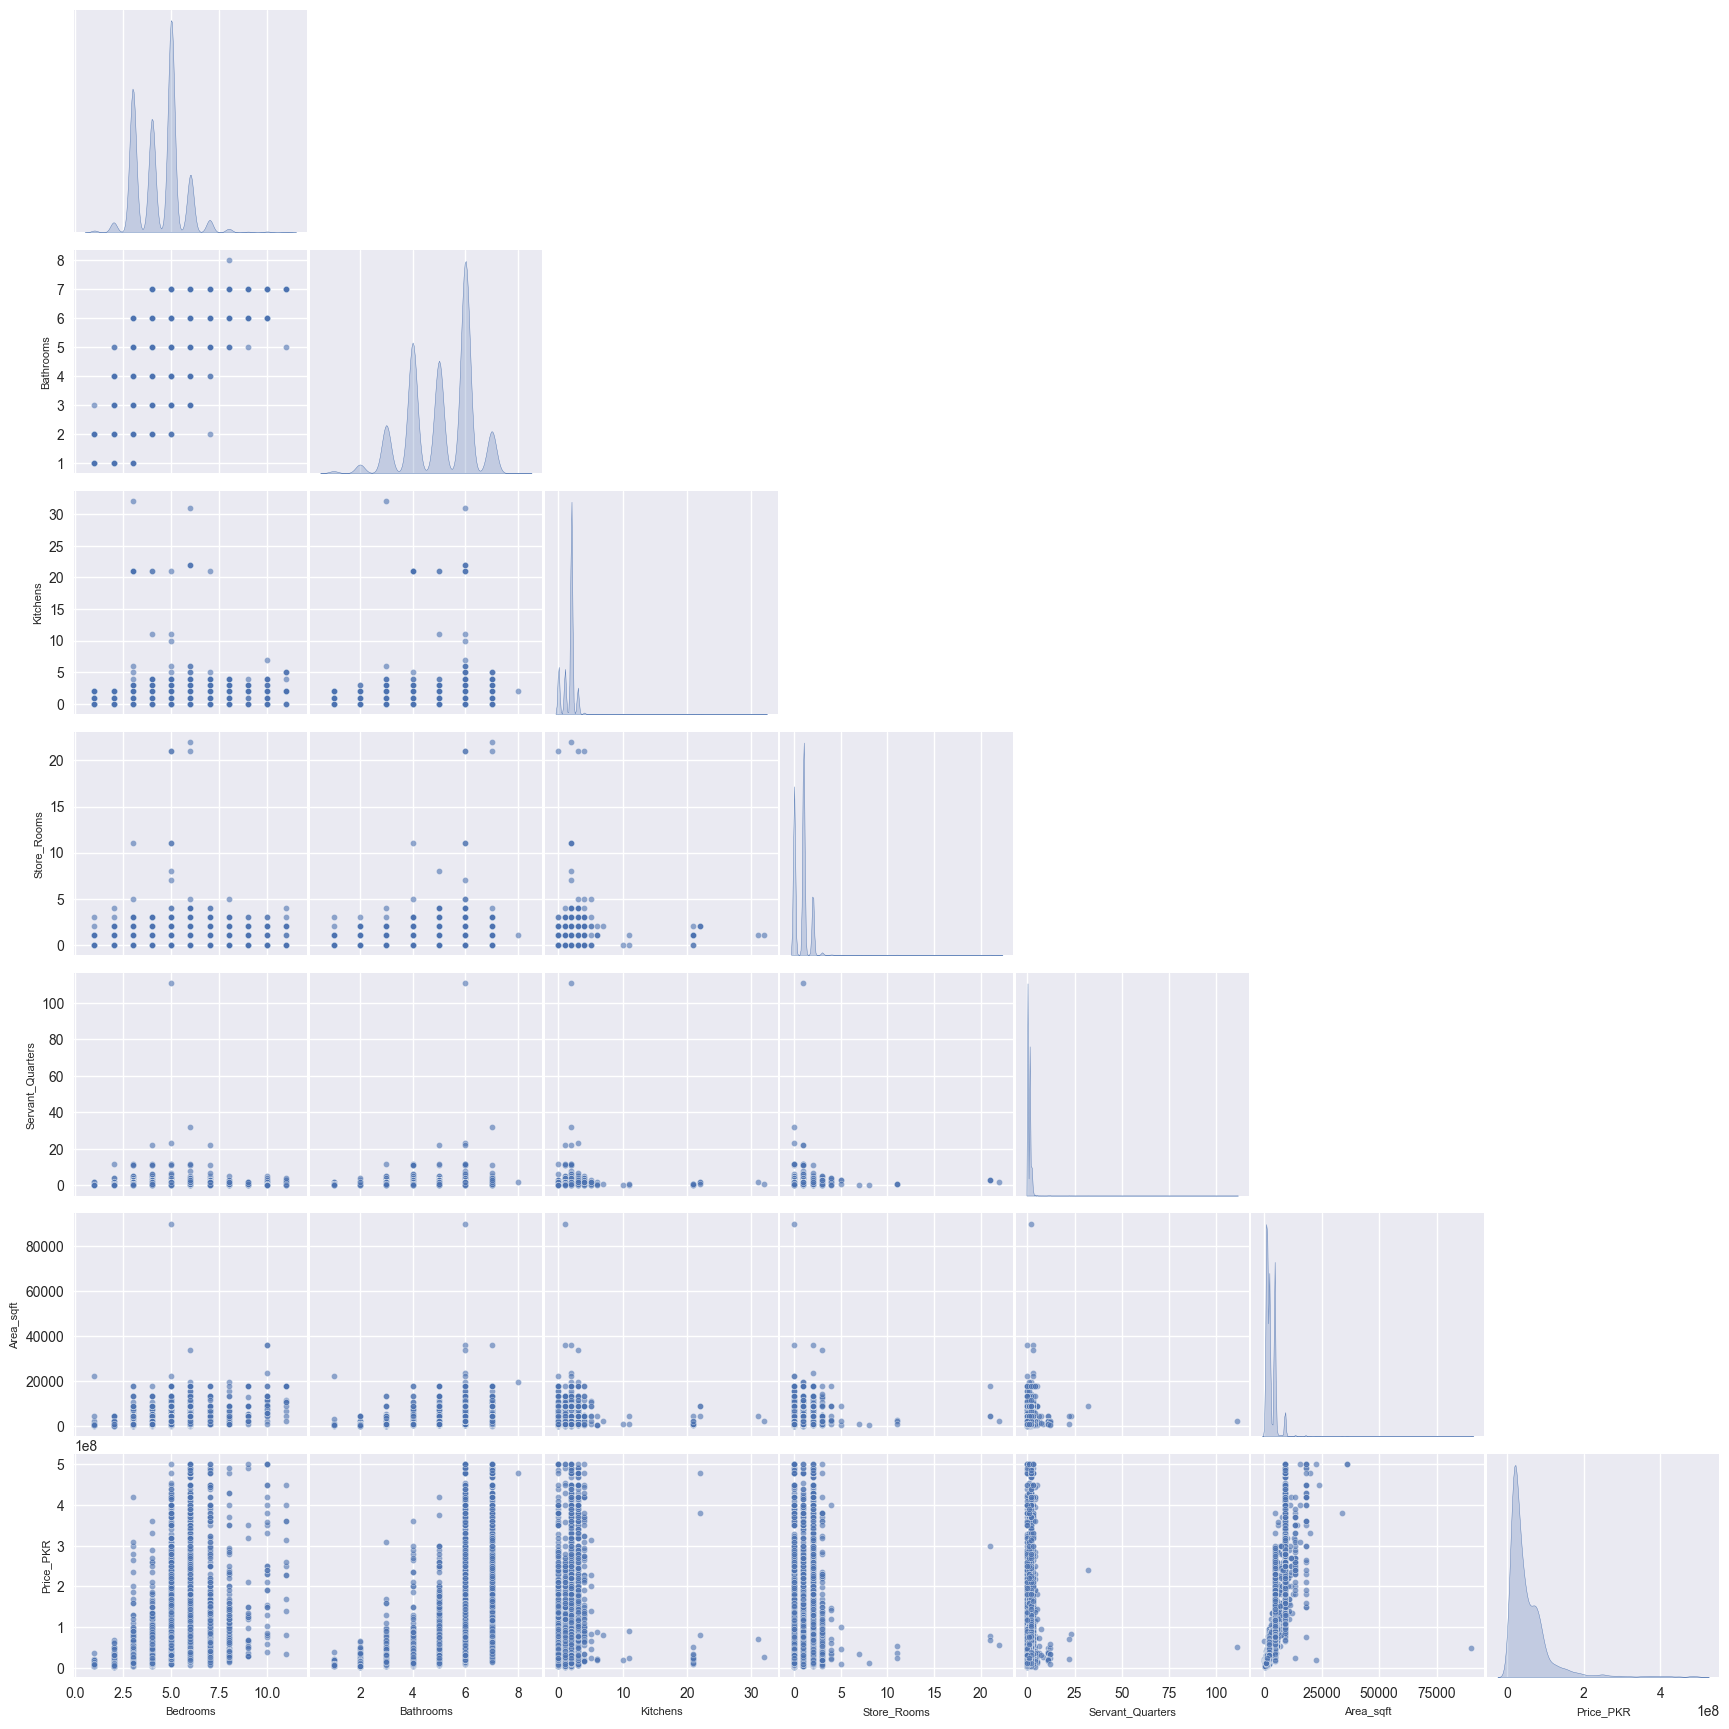

In [41]:
sns.pairplot(
    lohor_dataset[num_cols],
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 20}
)

plt.show()

### Saving Final Dataset

In [42]:
os.chdir(ROOT_DIR/INTERIM)
lohor_dataset.to_csv("cln_lohore_dataset.csv",index = False)
print("file Saved Successfully!")

file Saved Successfully!
